<a href="https://colab.research.google.com/github/RohanKJoseph/IPRS_Tasks/blob/main/ML_TASK%E2%80%9003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Practical Study of Machine Learning Classifiers on Iris Species Data

In [22]:
#importing the required libraries...
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
# from sklearn.naive_bayes import NaiveBayesClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ImportError: cannot import name 'NaiveBayesClassifier' from 'sklearn.naive_bayes' (/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py)

## Load and Preprocess Dataset

In [10]:
#Load the Iris dataset into a Pandas DataFrame
data = pd.read_csv("/content/Iris-kaggle-dataset.csv")
df = pd.DataFrame(data)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
#Perform necessary preprocessing
print(df.isnull().sum())  #no missing values are there..

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [8]:
# Prepare features (X) and target variable (y)
X = df.drop(columns=['Species'])
y = df['Species']

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
# Split dataset into train set and test set
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.20, random_state=42, stratify=y)
print(f"Dataset Split Complete. Train Shape: {X_train.shape} | Test Shape: {X_test.shape}\n")

Dataset Split Complete. Train Shape: (120, 5) | Test Shape: (30, 5)



##Implement Models

In [16]:
results = {}

#Implement K-Nearest Neighbors (KNN)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
results['KNN'] = knn.predict(X_test)

In [18]:
#Implement Support Vector Machine (SVM) with all kernel types:

kernels = ['linear', 'rbf', 'sigmoid', 'poly']
for i in kernels:
    svm = SVC(kernel=i, random_state=42)
    svm.fit(X_train, y_train)
    results[f'SVM_{i.upper()}'] = svm.predict(X_test)

## Implement Additional Algorithm

In [28]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
results['Logistic_Regression'] = lr.predict(X_test)

In [24]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
results['Decision_Tree'] = dt.predict(X_test)

In [25]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
results['Random_Forest'] = rf.predict(X_test)

In [29]:
# nb = NaiveBayesClassifier()
# nb.fit(X_train, y_train)
# results['Naive_Bayes'] = nb.predict(X_test)

##Model Evaluation


In [31]:
print("=== Step 4: Model Evaluation Reports ===")
for model_name, predictions in results.items():
    acc = accuracy_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)

    print("\n" + "="*20)
    print(f" MODEL: {model_name}")
    print("="*20)
    print(f"Accuracy Score: {acc:.4f}\n")
    print("Confusion Matrix:")
    print(cm)

=== Step 4: Model Evaluation Reports ===

 MODEL: KNN
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

 MODEL: SVM_LINEAR
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

 MODEL: SVM_RBF
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

 MODEL: SVM_SIGMOID
Accuracy Score: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

 MODEL: SVM_POLY
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

 MODEL: Random_Forest
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

 MODEL: Decision_Tree
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

 MODEL: Logistic_Regression
Accuracy Score: 1.0000

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


##comparison


/tmp/ipykernel_312/2035689929.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracy_series.index, y=accuracy_series.values, palette='viridis')


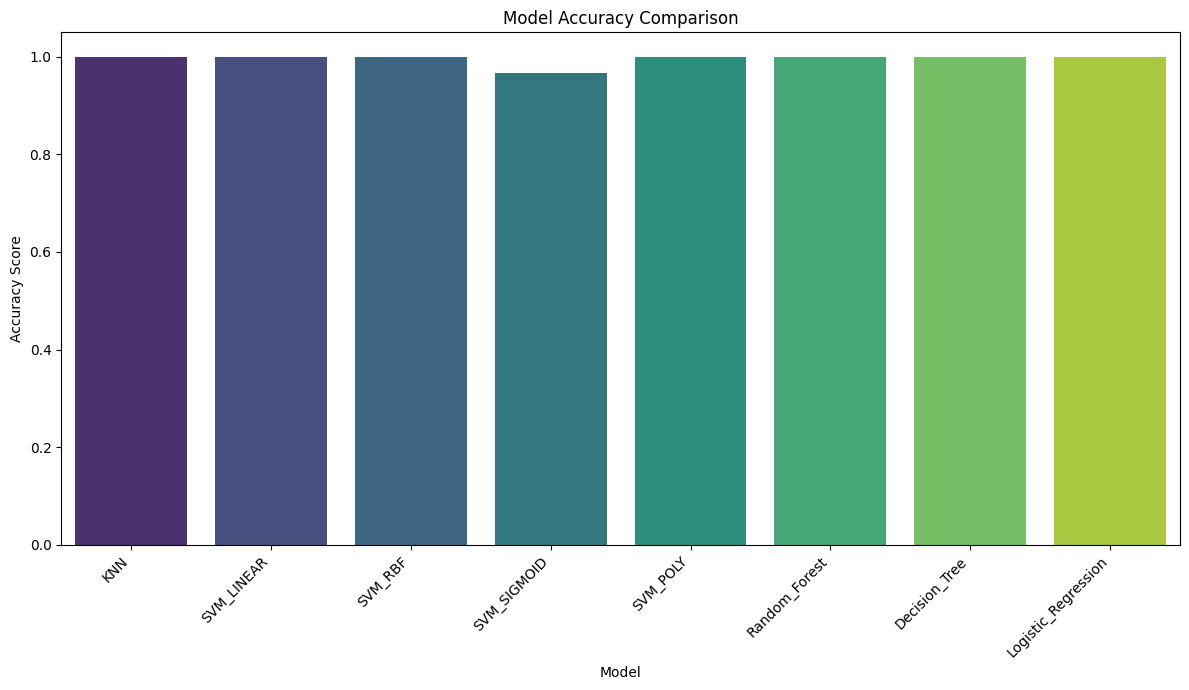

In [32]:
accuracy_scores = {}
for model_name, predictions in results.items():
    acc = accuracy_score(y_test, predictions)
    accuracy_scores[model_name] = acc

# Convert to a pandas Series for easy plotting
accuracy_series = pd.Series(accuracy_scores)

plt.figure(figsize=(12, 7))
sns.barplot(x=accuracy_series.index, y=accuracy_series.values, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1.05) # Set y-axis limit from 0 to 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()